In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pingouin as pg


In [2]:
baseball_df=pd.read_csv('full_baseball_data_with_status.csv')
baseball_df.head()

,Name,HOF_status,G,PA,HR,R,RBI,SB,AVG,OBP,SLG,wRC+,Off,Def,WAR
0,Mike Trout,active,1648,7203,404,1196,1018,214,0.294,0.406,0.570,166,608.3,-7.9,87.2
1,Freddie Freeman,active,2179,9363,367,1379,1322,104,0.300,0.386,0.511,141,467.0,-134.8,64.8
2,Mookie Betts,active,1531,6936,291,1166,913,196,0.290,0.369,0.512,136,349.1,30.4,62.6
3,Aaron Judge,active,1145,5002,368,873,830,65,0.294,0.413,0.615,178,449.7,-13.0,61.5
4,Francisco Lindor,active,1535,6848,279,1011,856,216,0.273,0.342,0.475,121,187.7,171.8,60.4


In [3]:
# data cleaning
# drop all active players
baseball_df_HOF = baseball_df[baseball_df['HOF_status'] != 'active']
baseball_df_active = baseball_df[baseball_df['HOF_status'] == 'active']
baseball_df_HOF.head()

,Name,HOF_status,G,PA,HR,R,RBI,SB,AVG,OBP,SLG,wRC+,Off,Def,WAR
66,Babe Ruth,HOF,2503,10616,714,2174,2217,123,0.342,0.474,0.690,194,1336.3,-18.6,167.0
67,Willie Mays,HOF,3005,12541,660,2068,1909,338,0.301,0.384,0.557,154,835.8,169.6,149.8
68,Ty Cobb,HOF,3035,13072,117,2246,1937,892,0.366,0.433,0.512,164,1027.9,-90.0,149.1
69,Honus Wagner,HOF,2792,11739,101,1736,1732,722,0.327,0.391,0.466,147,704.7,184.4,138.1
70,Hank Aaron,HOF,3298,13940,755,2174,2297,240,0.305,0.374,0.555,153,882.0,-61.2,136.3


In [4]:
# drop name column
baseball_df_HOF = baseball_df_HOF.drop(columns=['Name'])

In [5]:
# convert HOF_status to a binary variable
def convert_HOF_status(status):
    if status == 'HOF':
        return 1
    else:
        return 0
baseball_df_HOF['HOF_status'] = baseball_df_HOF['HOF_status'].apply(convert_HOF_status)
baseball_df_HOF.head()

,HOF_status,G,PA,HR,R,RBI,SB,AVG,OBP,SLG,wRC+,Off,Def,WAR
66,1,2503,10616,714,2174,2217,123,0.342,0.474,0.690,194,1336.3,-18.6,167.0
67,1,3005,12541,660,2068,1909,338,0.301,0.384,0.557,154,835.8,169.6,149.8
68,1,3035,13072,117,2246,1937,892,0.366,0.433,0.512,164,1027.9,-90.0,149.1
69,1,2792,11739,101,1736,1732,722,0.327,0.391,0.466,147,704.7,184.4,138.1
70,1,3298,13940,755,2174,2297,240,0.305,0.374,0.555,153,882.0,-61.2,136.3


<Axes: >

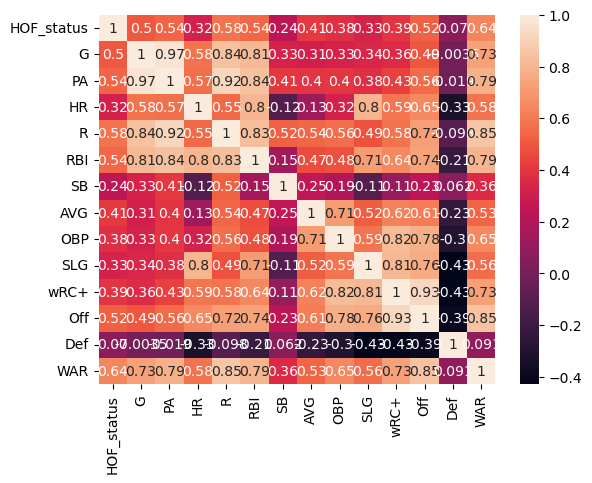

In [6]:
# check correlations
correlation = baseball_df_HOF.corr()
sns.heatmap(correlation, annot=True)

In [7]:
# drop Def and SB as they are lowly correlated with HOF_status and drop G as it is highly correlated with PA
def drop_columns(df, columns_to_drop):
    """
    This function drops specified columns from a DataFrame
    """
    return df.drop(columns=columns_to_drop)
baseball_df_HOF = drop_columns(baseball_df_HOF, ['Def', 'SB', 'G'])
baseball_df_HOF.head()

,HOF_status,PA,HR,R,RBI,AVG,OBP,SLG,wRC+,Off,WAR
66,1,10616,714,2174,2217,0.342,0.474,0.690,194,1336.3,167.0
67,1,12541,660,2068,1909,0.301,0.384,0.557,154,835.8,149.8
68,1,13072,117,2246,1937,0.366,0.433,0.512,164,1027.9,149.1
69,1,11739,101,1736,1732,0.327,0.391,0.466,147,704.7,138.1
70,1,13940,755,2174,2297,0.305,0.374,0.555,153,882.0,136.3


In [8]:
hof_only = baseball_df_HOF[baseball_df_HOF['HOF_status'] == 1]

hof_only.describe().round(2)

,HOF_status,PA,HR,R,RBI,AVG,OBP,SLG,wRC+,Off,WAR
count,172.0,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00,172.00
mean,1.0,9206.40,241.23,1335.90,1249.48,0.30,0.37,0.47,127.27,327.77,65.97
std,0.0,1976.98,178.00,340.51,373.32,0.02,0.03,0.06,18.86,245.67,25.65
min,1.0,5099.00,11.00,579.00,530.00,0.25,0.30,0.32,82.00,-248.00,16.60
25%,1.0,7739.00,90.50,1099.00,971.75,0.28,0.36,0.43,115.00,183.08,50.25
50%,1.0,9403.00,200.00,1305.00,1267.50,0.30,0.37,0.47,126.50,299.65,62.45
75%,1.0,10482.25,376.75,1579.75,1529.00,0.32,0.39,0.50,139.00,443.50,72.72
max,1.0,13991.00,755.00,2295.00,2297.00,0.37,0.48,0.69,194.00,1336.30,167.00


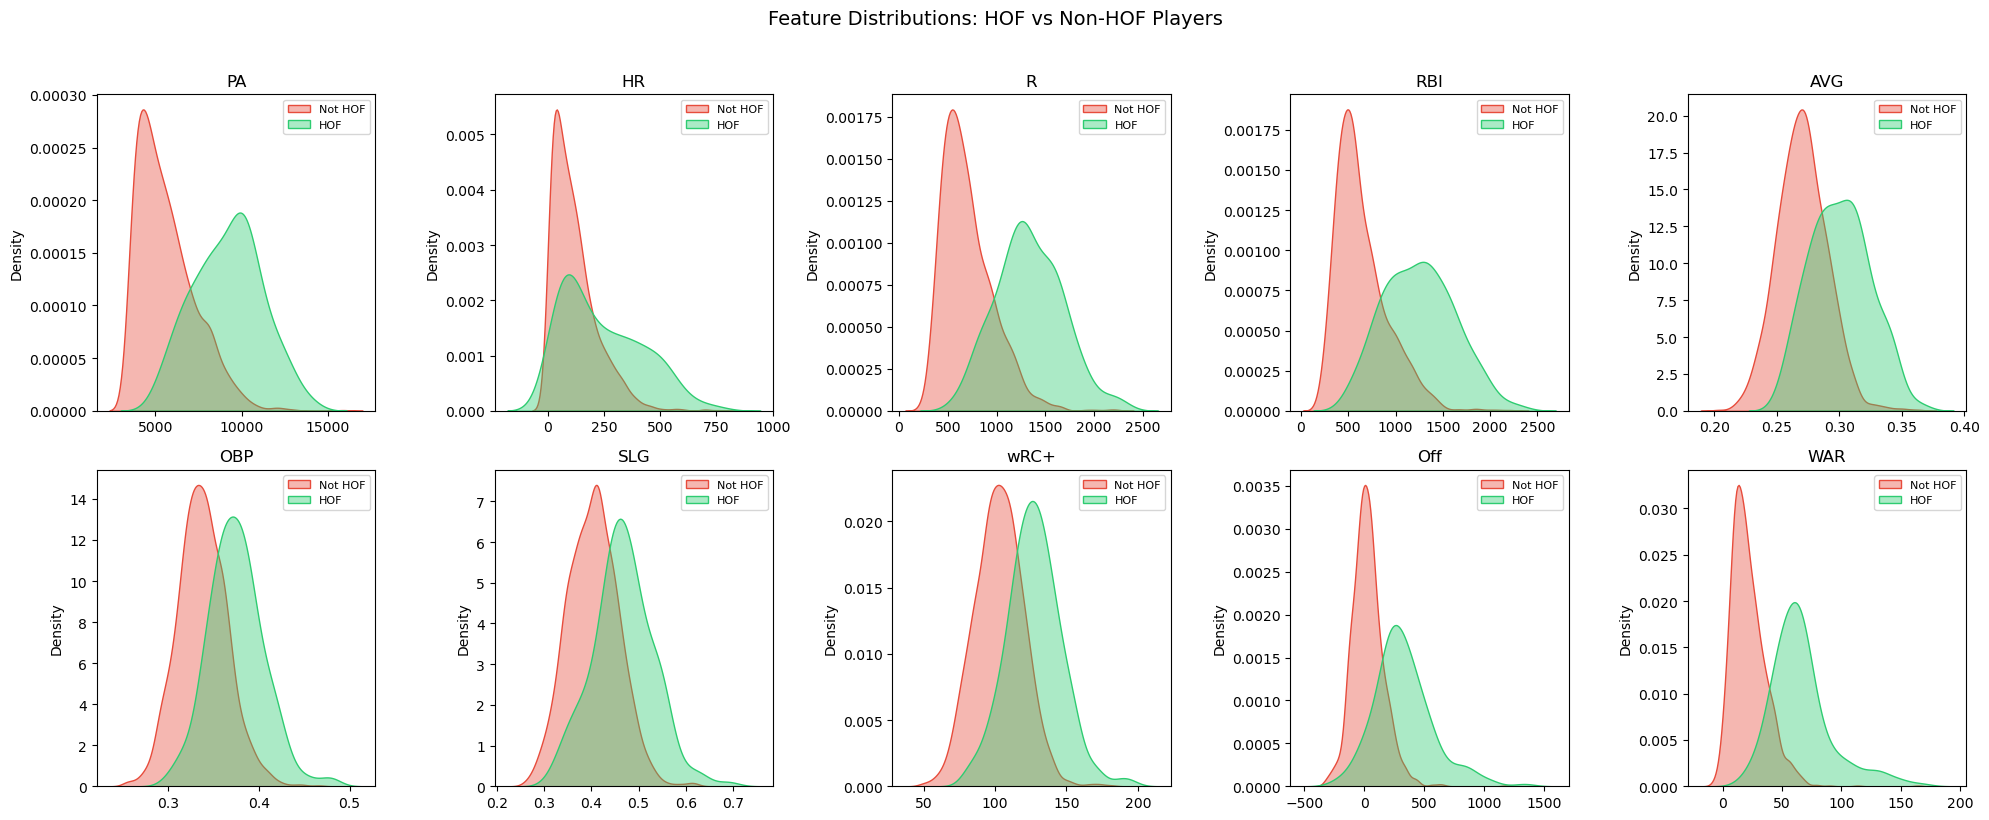

In [9]:
# Distribution of each feature by HOF status
features = baseball_df_HOF.drop(columns='HOF_status').columns

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    for status, label, color in [(0, 'Not HOF', '#e74c3c'), (1, 'HOF', '#2ecc71')]:
        subset = baseball_df_HOF[baseball_df_HOF['HOF_status'] == status][feature]
        sns.kdeplot(subset, ax=axes[i], label=label, color=color, fill=True, alpha=0.4)
    
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions: HOF vs Non-HOF Players', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [10]:
# analysis of variance on each of our variables to determine which ones have a statistically significant impact
def run_anova(df, target='HOF_status'):
    """
    Runs a one-way ANOVA for each feature in df against the target column.
    """
    features = df.drop(columns=target).columns
    anova_results = []

    for feature in features:
        result = pg.anova(data=df, dv=feature, between=target)
        anova_results.append({
            'Feature': feature,
            'F-Statistic': result['F'].values[0].round(3),
            'p-value': result['p_unc'].values[0],
            'Significant (p < 0.05)': result['p_unc'].values[0] < 0.05
        })

    return pd.DataFrame(anova_results).sort_values('p-value')


anova_df = run_anova(baseball_df_HOF)
anova_df

,Feature,F-Statistic,p-value,Significant (p < 0.05)
9,WAR,1160.469,2.931193e-194,True
2,R,846.314,2.682767e-151,True
3,RBI,708.993,8.099695e-131,True
0,PA,680.735,1.854999e-126,True
8,Off,638.891,6.621436e-120,True
4,AVG,340.378,2.051257e-69,True
7,wRC+,309.629,8.573646e-64,True
5,OBP,279.260,3.729801e-58,True
6,SLG,207.168,2.098128e-44,True
1,HR,194.492,6.241166e-42,True


In [12]:
baseball_df_HOF.to_csv('baseball_df_HOF.csv', index=False)
baseball_df_active.to_csv('baseball_df_active.csv', index=False)